In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [3]:
import pandas as pd

path = "C:/Users/USER/Documents/Personal Project/sales-performance-python/sales_data.csv"

df = pd.read_csv(path, encoding="latin1")
df.head()


,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


In [4]:
df.shape

(2823, 25)

In [5]:
list(df.columns)


['ORDERNUMBER',
 'QUANTITYORDERED',
 'PRICEEACH',
 'ORDERLINENUMBER',
 'SALES',
 'ORDERDATE',
 'STATUS',
 'QTR_ID',
 'MONTH_ID',
 'YEAR_ID',
 'PRODUCTLINE',
 'MSRP',
 'PRODUCTCODE',
 'CUSTOMERNAME',
 'PHONE',
 'ADDRESSLINE1',
 'ADDRESSLINE2',
 'CITY',
 'STATE',
 'POSTALCODE',
 'COUNTRY',
 'TERRITORY',
 'CONTACTLASTNAME',
 'CONTACTFIRSTNAME',
 'DEALSIZE']

In [6]:
df.head(3)


,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium


In [7]:
# Make column names lowercase for easier use
df.columns = df.columns.str.lower()

list(df.columns)
# Convert orderdate to datetime
df["orderdate"] = pd.to_datetime(df["orderdate"])

df[["orderdate"]].head()
df.isna().sum().sort_values(ascending=False).head(10)


addressline2       2521
state              1486
territory          1074
postalcode           76
sales                 0
quantityordered       0
priceeach             0
orderlinenumber       0
ordernumber           0
month_id              0
dtype: int64

In [8]:
# Create year and month from orderdate
df["year"] = df["orderdate"].dt.year
df["month"] = df["orderdate"].dt.month

df[["orderdate", "year", "month"]].head()


,orderdate,year,month
0,2003-02-24,2003,2
1,2003-05-07,2003,5
2,2003-07-01,2003,7
3,2003-08-25,2003,8
4,2003-10-10,2003,10


In [9]:
total_sales = df["sales"].sum()

total_sales


np.float64(10032628.85)

In [10]:
sales_by_year = (
    df.groupby("year")["sales"]
    .sum()
    .sort_index()
)

sales_by_year


year
2003    3516979.54
2004    4724162.60
2005    1791486.71
Name: sales, dtype: float64

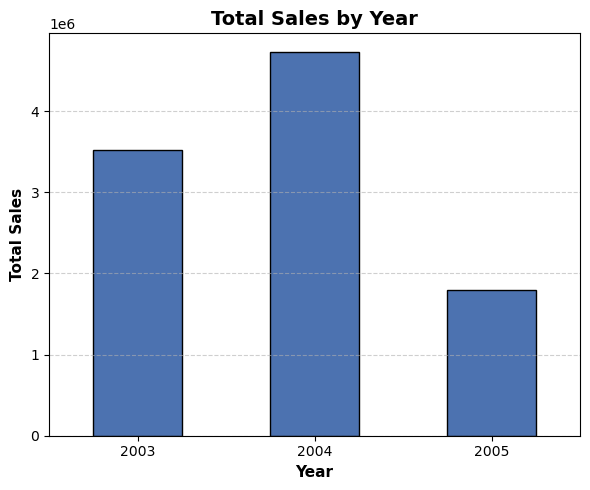

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

sales_by_year.plot(
    kind="bar",
    color="#4C72B0",   # cool blue
    edgecolor="black"
)

plt.title(
    "Total Sales by Year",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel(
    "Year",
    fontsize=11,
    fontweight="bold"
)
plt.ylabel(
    "Total Sales",
    fontsize=11,
    fontweight="bold"
)

plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(6, 5))

sales_by_year.plot(
    kind="bar",
    color="#4C72B0",
    edgecolor="black"
)

plt.title("Total Sales by Year", fontsize=14, fontweight="bold")
plt.xlabel("Year", fontsize=11, fontweight="bold")
plt.ylabel("Total Sales", fontsize=11, fontweight="bold")

plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig("../visuals/sales_by_year.png", dpi=300)
plt.close()


In [17]:
sales_by_product = (
    df.groupby("productline")["sales"]
    .sum()
    .sort_values(ascending=False)
)

sales_by_product


productline
Classic Cars        3919615.66
Vintage Cars        1903150.84
Motorcycles         1166388.34
Trucks and Buses    1127789.84
Planes               975003.57
Ships                714437.13
Trains               226243.47
Name: sales, dtype: float64

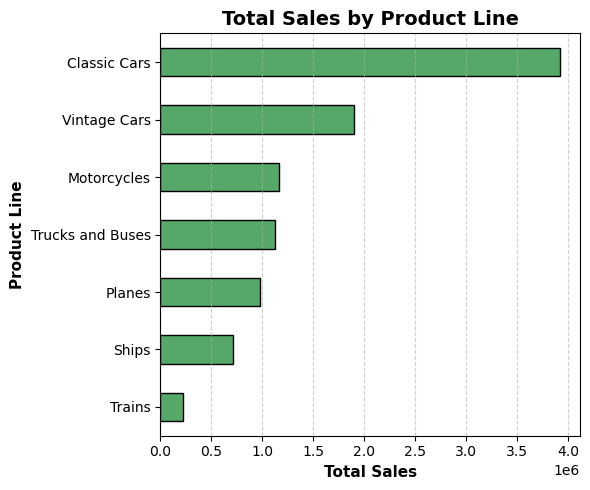

In [18]:
plt.figure(figsize=(6, 5))

sales_by_product.plot(
    kind="barh",
    color="#55A868",   # cool green
    edgecolor="black"
)

plt.title(
    "Total Sales by Product Line",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel(
    "Total Sales",
    fontsize=11,
    fontweight="bold"
)
plt.ylabel(
    "Product Line",
    fontsize=11,
    fontweight="bold"
)

plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()
